In [1]:
# ============================================================
# EFFICIENTNETB0 - ADVANCED PIPELINE
# CHEST X-RAY PNEUMONIA CLASSIFICATION
# OPTIMIZED FOR SMALL DATASETS
# ============================================================

# ============================================================
# 1. INSTALLS
# ============================================================

!pip install -q opencv-python

# ============================================================
# 2. IMPORTS
# ============================================================

import os
import json
import numpy as np
import pandas as pd

import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    f1_score
)

from sklearn.utils.class_weight import compute_class_weight

In [2]:
# ============================================================
# 3. CONFIG
# ============================================================

from google.colab import drive

drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/UFS - Mestrado/Visão Computacional/DataSets/chest ray-x pneumonia'

PROJECT_DIR = '/content/drive/MyDrive/ChestXRayProject'

MODEL_DIR = os.path.join(PROJECT_DIR, 'models')

HISTORY_DIR = os.path.join(PROJECT_DIR, 'histories')

FIGURE_DIR = os.path.join(PROJECT_DIR, 'figures')

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(HISTORY_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

IMG_SIZE = (224,224)

BATCH_SIZE = 16

EPOCHS = 30

SEED = 42

Mounted at /content/drive


In [3]:
# ============================================================
# 4. LOAD DATASETS
# ============================================================

train_ds = tf.keras.preprocessing.image_dataset_from_directory(

    DATA_DIR + "/train",

    validation_split=0.2,

    subset="training",

    seed=SEED,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    label_mode='binary'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(

    DATA_DIR + "/train",

    validation_split=0.2,

    subset="validation",

    seed=SEED,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    label_mode='binary'
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(

    DATA_DIR + "/test",

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    label_mode='binary'
)


Found 5232 files belonging to 2 classes.
Using 4186 files for training.
Found 5232 files belonging to 2 classes.
Using 1046 files for validation.
Found 624 files belonging to 2 classes.


In [4]:
# ============================================================
# 5. CLASS WEIGHTS
# ============================================================

y_train = []

for _, labels in train_ds:

    y_train.extend(labels.numpy().flatten())

y_train = np.array(y_train)

class_weights = compute_class_weight(

    class_weight='balanced',

    classes=np.unique(y_train),

    y=y_train
)

class_weights = {

    0: class_weights[0],

    1: class_weights[1]
}

print(class_weights)

{0: np.float64(1.9061930783242258), 1: np.float64(0.6777849740932642)}


In [5]:
# ============================================================
# 6. PERFORMANCE OPTIMIZATION
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)

val_ds = val_ds.cache().prefetch(AUTOTUNE)

test_ds = test_ds.cache().prefetch(AUTOTUNE)



In [6]:
# ============================================================
# 7. DATA AUGMENTATION
# ============================================================

data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.08),

    layers.RandomZoom(0.08),

    layers.RandomContrast(0.05),

    layers.RandomBrightness(0.1)
])


In [7]:
# ============================================================
# 8. BUILD MODEL
# ============================================================

def build_efficientnetb0():

    # ========================================================
    # BACKBONE
    # ========================================================

    base_model = EfficientNetB0(

        include_top=False,

        weights='imagenet',

        input_shape=(224,224,3)
    )

    # ========================================================
    # FINE TUNING
    # ========================================================

    base_model.trainable = True

    for layer in base_model.layers[:-40]:

        layer.trainable = False

    # ========================================================
    # INPUT
    # ========================================================

    inputs = tf.keras.Input(

        shape=(224,224,3)
    )

    # ========================================================
    # AUGMENTATION
    # ========================================================

    x = data_augmentation(inputs)

    # ========================================================
    # PREPROCESSING
    # ========================================================

    x = tf.keras.applications.efficientnet.preprocess_input(x)

    # ========================================================
    # BACKBONE
    # ========================================================

    x = base_model(

        x,

        training=False
    )

    # ========================================================
    # CLASSIFIER HEAD
    # ========================================================

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.BatchNormalization()(x)

    x = layers.Dropout(0.4)(x)

    x = layers.Dense(

        256,

        activation='relu',

        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(

        1,

        activation='sigmoid'
    )(x)

    model = tf.keras.Model(

        inputs,

        outputs
    )

    return model

# ============================================================
# 9. CREATE MODEL
# ============================================================

model = build_efficientnetb0()

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,908 (16.72 MB)

 Trainable params: 2,381,969 (9.09 MB)

 Non-trainable params: 2,001,939 (7.64 MB)

In [8]:
# ============================================================
# 10. LEARNING RATE SCHEDULE
# ============================================================

steps_per_epoch = tf.data.experimental.cardinality(train_ds).numpy()

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(

    initial_learning_rate=1e-4,

    decay_steps=steps_per_epoch * EPOCHS
)

In [9]:
# ============================================================
# 11. COMPILE
# ============================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=lr_schedule
    ),

    loss=tf.keras.losses.BinaryFocalCrossentropy(

        gamma=2.0,

        apply_class_balancing=True
    ),

    metrics=[

        'accuracy',

        tf.keras.metrics.Precision(
            name='precision'
        ),

        tf.keras.metrics.Recall(
            name='recall'
        ),

        tf.keras.metrics.AUC(
            name='auc'
        )
    ]
)

In [10]:
# ============================================================
# 12. CALLBACKS
# ============================================================

callbacks = [

    tf.keras.callbacks.EarlyStopping(

        monitor='val_auc',

        mode='max',

        patience=6,

        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(

        filepath=f'{MODEL_DIR}/EfficientNetB0.keras',

        monitor='val_auc',

        mode='max',

        save_best_only=False
    ),

    tf.keras.callbacks.CSVLogger(

        f'{HISTORY_DIR}/EfficientNetB0_training.csv',

        append=False
    )
]

In [11]:
# ============================================================
# 13. TRAIN
# ============================================================

history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    callbacks=callbacks,

    class_weight=class_weights
)

Epoch 1/30
262/262 ━━━━━━━━━━━━━━━━━━━━ 666s 2s/step - accuracy: 0.7592 - auc: 0.9015 - loss: 0.4994 - precision: 0.9557 - recall: 0.7063 - val_accuracy: 0.8509 - val_auc: 0.9731 - val_loss: 0.4406 - val_precision: 0.9923 - val_recall: 0.8101
Epoch 2/30
262/262 ━━━━━━━━━━━━━━━━━━━━ 521s 2s/step - accuracy: 0.8290 - auc: 0.9553 - loss: 0.4430 - precision: 0.9825 - recall: 0.7821 - val_accuracy: 0.8977 - val_auc: 0.9804 - val_loss: 0.4104 - val_precision: 0.9859 - val_recall: 0.8780
Epoch 3/30
262/262 ━━━━━━━━━━━━━━━━━━━━ 573s 2s/step - accuracy: 0.8488 - auc: 0.9662 - loss: 0.4131 - precision: 0.9835 - recall: 0.8086 - val_accuracy: 0.8327 - val_auc: 0.9881 - val_loss: 0.4235 - val_precision: 0.9968 - val_recall: 0.7824
Epoch 4/30
262/262 ━━━━━━━━━━━━━━━━━━━━ 524s 2s/step - accuracy: 0.8636 - auc: 0.9695 - loss: 0.3954 - precision: 0.9839 - recall: 0.8287 - val_accuracy: 0.9130 - val_auc: 0.9909 - val_loss: 0.3769 - val_precision: 0.9958 - val_recall: 0.8893
Epoch 5/30
262/262 ━━━━━━━━━

In [12]:
# ============================================================
# 14. SAVE HISTORY
# ============================================================

history_df = pd.DataFrame(

    history.history
)

history_df.to_csv(

    f'{HISTORY_DIR}/EfficientNetB0_history.csv',

    index=False
)

with open(

    f'{HISTORY_DIR}/EfficientNetB0_history.json',

    'w'
) as f:

    json.dump(

        history.history,

        f
    )

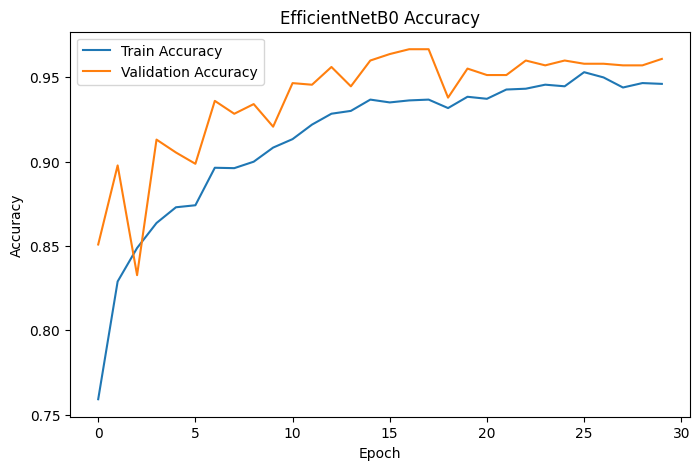

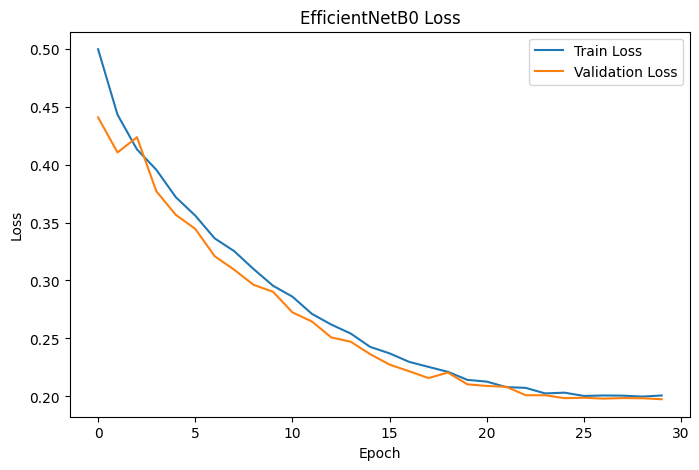

In [13]:
# ============================================================
# 15. PLOT HISTORY
# ============================================================

def plot_history(history):

    # ========================================================
    # ACCURACY
    # ========================================================

    plt.figure(figsize=(8,5))

    plt.plot(

        history.history['accuracy'],

        label='Train Accuracy'
    )

    plt.plot(

        history.history['val_accuracy'],

        label='Validation Accuracy'
    )

    plt.title('EfficientNetB0 Accuracy')

    plt.xlabel('Epoch')

    plt.ylabel('Accuracy')

    plt.legend()

    plt.savefig(

        f'{FIGURE_DIR}/efficientnetb0_accuracy.png',

        bbox_inches='tight'
    )

    plt.show()

    # ========================================================
    # LOSS
    # ========================================================

    plt.figure(figsize=(8,5))

    plt.plot(

        history.history['loss'],

        label='Train Loss'
    )

    plt.plot(

        history.history['val_loss'],

        label='Validation Loss'
    )

    plt.title('EfficientNetB0 Loss')

    plt.xlabel('Epoch')

    plt.ylabel('Loss')

    plt.legend()

    plt.savefig(

        f'{FIGURE_DIR}/efficientnetb0_loss.png',

        bbox_inches='tight'
    )

    plt.show()

plot_history(history)

In [14]:
# ============================================================
# 16. TEST TIME AUGMENTATION
# ============================================================

def tta_predict(model, images, n=5):

    preds = []

    for _ in range(n):

        augmented = data_augmentation(

            images,

            training=True
        )

        pred = model.predict(

            augmented,

            verbose=0
        )

        preds.append(pred)

    return np.mean(

        preds,

        axis=0
    )


In [15]:
# ============================================================
# 17. PREDICTIONS
# ============================================================

def get_predictions(model, dataset):

    y_true = []

    y_pred = []

    for x, y in dataset:

        preds = tta_predict(

            model,

            x,

            n=5
        )

        y_true.extend(

            y.numpy()
        )

        y_pred.extend(

            preds.flatten()
        )

    return np.array(y_true), np.array(y_pred)

y_true, y_pred = get_predictions(

    model,

    test_ds
)


In [16]:
# ============================================================
# 18. THRESHOLD OPTIMIZATION
# ============================================================

thresholds = np.arange(

    0.1,

    0.9,

    0.01
)

best_threshold = 0

best_f1 = 0

for t in thresholds:

    preds = (

        y_pred > t
    ).astype(int)

    f1 = f1_score(

        y_true,

        preds
    )

    if f1 > best_f1:

        best_f1 = f1

        best_threshold = t

print("\nBEST THRESHOLD:", best_threshold)

print("BEST F1:", best_f1)


BEST THRESHOLD: 0.7699999999999997
BEST F1: 0.9395109395109396



CLASSIFICATION REPORT

              precision    recall  f1-score   support

      NORMAL       0.89      0.91      0.90       234
   PNEUMONIA       0.94      0.94      0.94       390

    accuracy                           0.92       624
   macro avg       0.92      0.92      0.92       624
weighted avg       0.92      0.92      0.92       624



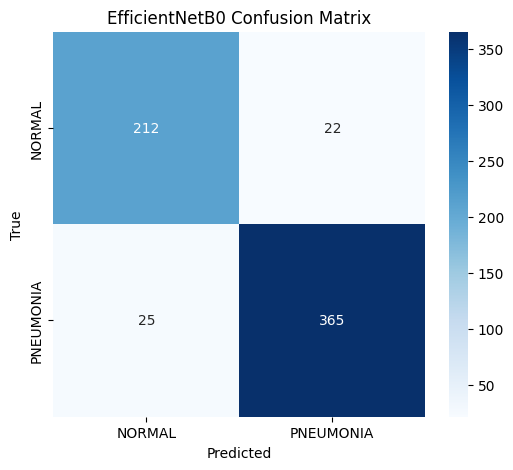

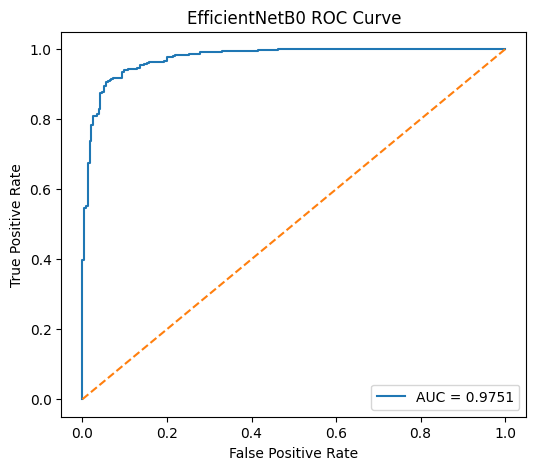


AUC SCORE: 0.9751


In [17]:
# ============================================================
# 19. FINAL PREDICTIONS
# ============================================================

y_pred_bin = (

    y_pred > best_threshold
).astype(int)

# ============================================================
# 20. CLASSIFICATION REPORT
# ============================================================

print("\nCLASSIFICATION REPORT\n")

print(

    classification_report(

        y_true,

        y_pred_bin,

        target_names=[

            'NORMAL',

            'PNEUMONIA'
        ]
    )
)

# ============================================================
# 21. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    y_true,

    y_pred_bin
)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=[

        'NORMAL',

        'PNEUMONIA'
    ],

    yticklabels=[

        'NORMAL',

        'PNEUMONIA'
    ]
)

plt.title('EfficientNetB0 Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('True')

plt.savefig(

    f'{FIGURE_DIR}/efficientnetb0_confusion_matrix.png',

    bbox_inches='tight'
)

plt.show()

# ============================================================
# 22. ROC CURVE
# ============================================================

fpr, tpr, thresholds = roc_curve(

    y_true,

    y_pred
)

roc_auc = auc(

    fpr,

    tpr
)

plt.figure(figsize=(6,5))

plt.plot(

    fpr,

    tpr,

    label=f'AUC = {roc_auc:.4f}'
)

plt.plot([0,1], [0,1], '--')

plt.title('EfficientNetB0 ROC Curve')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.legend()

plt.savefig(

    f'{FIGURE_DIR}/efficientnetb0_roc_curve.png',

    bbox_inches='tight'
)

plt.show()

print(f"\nAUC SCORE: {roc_auc:.4f}")

In [20]:
# ============================================================
# VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    history['val_accuracy'],
    label='EfficientNetB0'
)

plt.title('Validation Accuracy Comparison')

plt.xlabel('Epoch')

plt.ylabel('Validation Accuracy')

plt.legend()

plt.grid()

plt.show()

TypeError: 'History' object is not subscriptable

<Figure size 800x500 with 0 Axes>